In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity


##  Collaborative filtering

The recommendations are done based on the user’s behavior. History of the user plays an important role. For example, if the user ‘A’ likes ‘Coldplay’, ‘The Linkin Park’ and ‘Britney Spears’ while the user ‘B’ likes ‘Coldplay’, ‘The Linkin Park’ and ‘Taylor Swift’ then they have similar interests. So, there is a huge probability that the user ‘A’ would like ‘Taylor Swift’ and the user ‘B’ would like ‘Britney Spears’. This is the way collaborative filtering is done.

In general, Collaborative filtering (CF) is more commonly used than content-based systems because it usually gives better results and is relatively easy to understand (from an overall implementation perspective).

Collaborative filters can further be classified into two types:

1. user-user filtering
2. item-item filtering

Note: Since the dataset we used before did not have userId(which is necessary for collaborative filtering) let's load another dataset

In [2]:
ratings = pd.read_csv(r"C:\Users\MF'\Downloads\AI_project\ratings.csv")
movies = pd.read_csv(r"C:\Users\MF'\Downloads\AI_project\movies.csv")

In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:

#We can merge them together
data = pd.merge(ratings,movies,on='movieId')
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [6]:
#Selecting usefull features
data = data[['movieId','title','userId','rating']]
data.head()

,movieId,title,userId,rating
0,1,Toy Story (1995),1,4.0
1,3,Grumpier Old Men (1995),1,4.0
2,6,Heat (1995),1,4.0
3,47,Seven (a.k.a. Se7en) (1995),1,5.0
4,50,"Usual Suspects, The (1995)",1,5.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   movieId  100836 non-null  int64  
 1   title    100836 non-null  object 
 2   userId   100836 non-null  int64  
 3   rating   100836 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.1+ MB


In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
movieId,100836.0,19435.295718,35530.987199,1.0,1199.0,2991.0,8122.0,193609.0
userId,100836.0,326.127564,182.618491,1.0,177.0,325.0,477.0,610.0
rating,100836.0,3.501557,1.042529,0.5,3.0,3.5,4.0,5.0


In [9]:
data.shape

(100836, 4)

In [10]:
data.isna()

,movieId,title,userId,rating
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
100831,False,False,False,False
100832,False,False,False,False
100833,False,False,False,False
100834,False,False,False,False


In [13]:
data.isna().sum()

movieId    0
title      0
userId     0
rating     0
dtype: int64

In [15]:
data.to_csv("New_dataset.csv", index=False)


In [14]:
n_users = data['userId'].nunique()
n_items = data['movieId'].nunique()

print('Num. of Users: '+ str(n_users))
print('Num of Movies: '+str(n_items))


Num. of Users: 610
Num of Movies: 9724


In [16]:
#groupby title and count how many people rated each and every movie & reseting index because I dont want title to be my index.
movie_rating_count = pd.DataFrame(data.groupby('title')['rating'].count().reset_index())
movie_rating_count = movie_rating_count.rename(columns={'rating':'total rating count'})
movie_rating_count.head()


,title,total rating count
0,'71 (2014),1
1,'Hellboy': The Seeds of Creation (2004),1
2,'Round Midnight (1986),2
3,'Salem's Lot (2004),1
4,'Til There Was You (1997),2


In [17]:
movie_rating_count.tail()

,title,total rating count
9714,eXistenZ (1999),22
9715,xXx (2002),24
9716,xXx: State of the Union (2005),5
9717,¡Three Amigos! (1986),26
9718,À nous la liberté (Freedom for Us) (1931),1


In [18]:
#adding new column called total rating count
rating_with_totalRatingCount = pd.merge(data,movie_rating_count,on='title')
rating_with_totalRatingCount.head()

,movieId,title,userId,rating,total rating count
0,1,Toy Story (1995),1,4.0,215
1,3,Grumpier Old Men (1995),1,4.0,52
2,6,Heat (1995),1,4.0,102
3,47,Seven (a.k.a. Se7en) (1995),1,5.0,203
4,50,"Usual Suspects, The (1995)",1,5.0,204


In [19]:

#only taking those movie whose total rating count is greater than 50
rating_popular_movie = rating_with_totalRatingCount[rating_with_totalRatingCount['total rating count']>=50]

In [20]:
rating_popular_movie.head()

,movieId,title,userId,rating,total rating count
0,1,Toy Story (1995),1,4.0,215
1,3,Grumpier Old Men (1995),1,4.0,52
2,6,Heat (1995),1,4.0,102
3,47,Seven (a.k.a. Se7en) (1995),1,5.0,203
4,50,"Usual Suspects, The (1995)",1,5.0,204


Now let's create a matrix that has the user ids on one access and the movie title on another axis. Each cell will then consist of the rating the user gave to that movie. Note there will be a lot of NaN values, because most people have not seen most of the movies.

In [21]:
# creating pivot table
movie_feature_df = rating_with_totalRatingCount.pivot_table(index='userId',columns='title',values='rating').fillna(0)
movie_feature_df.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 📊 Statistical Analysis

### 1. Distribution of Number of Ratings per User

<Axes: >

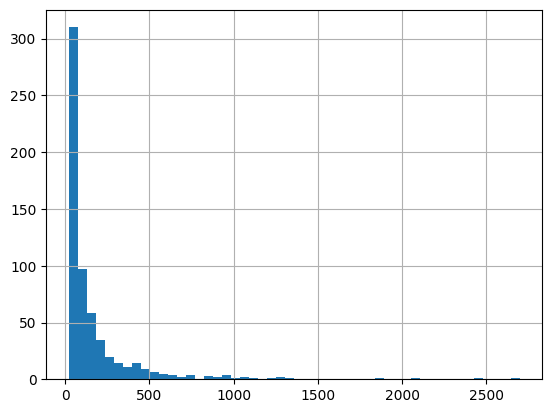

In [25]:
# Plotting the distribution of the number of ratings each user has made
data.groupby('userId')['rating'].count().hist(bins=50)


### 2. Distribution of Number of Ratings per Movie

<Axes: >

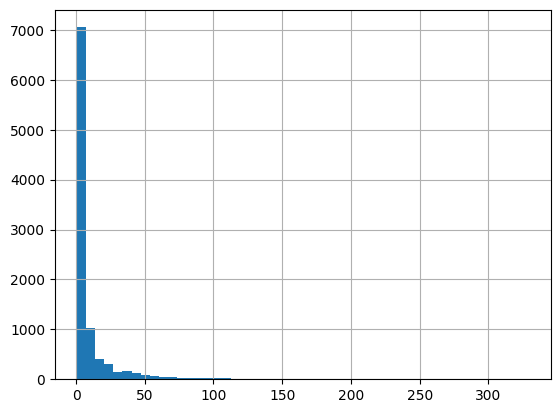

In [26]:
# Plotting the distribution of the number of ratings received by each movie
data.groupby('movieId')['rating'].count().hist(bins=50)


### 3. Distribution of Ratings

<Axes: >

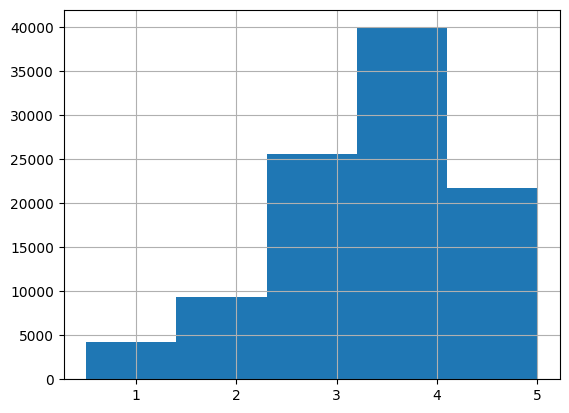

In [27]:
# Visualizing how ratings are distributed (e.g., how many 1-star, 2-star, etc.)
data['rating'].hist(bins=5)


### 4. Top Rated Movies by Count

In [28]:
# Displaying the movies that received the most number of ratings
movie_rating_count.sort_values('total rating count', ascending=False).head(10)


,title,total rating count
3158,Forrest Gump (1994),329
7593,"Shawshank Redemption, The (1994)",317
6865,Pulp Fiction (1994),307
7680,"Silence of the Lambs, The (1991)",279
5512,"Matrix, The (1999)",278
8001,Star Wars: Episode IV - A New Hope (1977),251
4662,Jurassic Park (1993),238
1337,Braveheart (1995),237
8363,Terminator 2: Judgment Day (1991),224
7421,Schindler's List (1993),220


### 5. Movies with the Highest Average Ratings

In [29]:
# Calculating the average rating for each movie and showing the top ones
data.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)


title
Karlson Returns (1970)                                                         5.0
Zeitgeist: Moving Forward (2011)                                               5.0
Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)    5.0
Dragons: Gift of the Night Fury (2011)                                         5.0
12 Angry Men (1997)                                                            5.0
Justice League: Doom (2012)                                                    5.0
Junior and Karlson (1968)                                                      5.0
Jump In! (2007)                                                                5.0
Human Condition III, The (Ningen no joken III) (1961)                          5.0
Louis Theroux: Law & Disorder (2008)                                           5.0
Name: rating, dtype: float64

### 6. Popular Movies with Both High Count and High Average Rating

In [30]:
# Combining total rating count and average rating for better movie insight
popular_movies = movie_rating_count.merge(data.groupby('title')['rating'].mean(), on='title')
popular_movies.columns = ['title', 'total rating count', 'average rating']


In [31]:
popular_movies

,title,total rating count,average rating
0,'71 (2014),1,4.000000
1,'Hellboy': The Seeds of Creation (2004),1,4.000000
2,'Round Midnight (1986),2,3.500000
3,'Salem's Lot (2004),1,5.000000
4,'Til There Was You (1997),2,4.000000
...,...,...,...
9714,eXistenZ (1999),22,3.863636
9715,xXx (2002),24,2.770833
9716,xXx: State of the Union (2005),5,2.000000
9717,¡Three Amigos! (1986),26,3.134615


The similarity can be computed with Pearson Correlation or Cosine Similarity. I am using "Pearson Correlation" in user-to-user cf and "Cosine Similarity" in item-to-item cf

### User-User collaborative filtering

In [32]:
user_similarity = cosine_similarity(movie_feature_df)
user_similarity_df = pd.DataFrame(user_similarity, index=movie_feature_df.index, columns=movie_feature_df.index)

In [33]:
def get_similar_users(user_id, top_n=10):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    return similar_users[1:top_n+1]  # بنستبعد نفسه


In [34]:
def get_user_recommendations(user_id, movie_feature_df, top_n=10):
    similar_users = get_similar_users(user_id)
    weighted_ratings = pd.Series(dtype='float64')
    
    for sim_user, similarity_score in similar_users.items():
        user_ratings = movie_feature_df.loc[sim_user]
        weighted_ratings = weighted_ratings.add(user_ratings * similarity_score, fill_value=0)
    
    user_seen_movies = movie_feature_df.loc[user_id][movie_feature_df.loc[user_id] > 0].index
    recommendations = weighted_ratings.drop(user_seen_movies)
    recommendations = recommendations.sort_values(ascending=False)
    
    return recommendations.head(top_n)


In [37]:
get_user_recommendations(user_id=1, movie_feature_df=movie_feature_df, top_n=10)


title
Terminator 2: Judgment Day (1991)    14.182299
Aliens (1986)                        13.925162
Sixth Sense, The (1999)              13.422015
Hunt for Red October, The (1990)     13.377867
Godfather, The (1972)                13.134550
2001: A Space Odyssey (1968)         13.031035
Die Hard (1988)                      12.862273
Blade Runner (1982)                  12.539779
Godfather: Part II, The (1974)       12.104995
Breakfast Club, The (1985)           12.080897
dtype: float64

### Item-Item collaborative filtering

In [38]:
item_similarity = cosine_similarity(movie_feature_df.T)
item_similarity_df = pd.DataFrame(item_similarity,index=movie_feature_df.columns,columns=movie_feature_df.columns)


In [39]:
# Function that takes in movie title and ratings as input and outputs most similar movies
def get_recomandation2(movie_name,ratings):
    similar_score = item_similarity_df[movie_name]*(ratings-2.5)
    similar_score = similar_score.sort_values(ascending=False)
    
    return similar_score

In [40]:
# Now lets make predictions
get_recomandation2('Toy Story (1995)',3).head(10)

title
Toy Story (1995)                                     0.500000
Toy Story 2 (1999)                                   0.286301
Jurassic Park (1993)                                 0.282818
Independence Day (a.k.a. ID4) (1996)                 0.282131
Star Wars: Episode IV - A New Hope (1977)            0.278694
Forrest Gump (1994)                                  0.273548
Lion King, The (1994)                                0.270573
Star Wars: Episode VI - Return of the Jedi (1983)    0.270545
Mission: Impossible (1996)                           0.269456
Groundhog Day (1993)                                 0.267084
Name: Toy Story (1995), dtype: float64